# 按区域划分的保险理赔频率贝叶斯分层模型

## 执行摘要

一家财产与意外险保险公司需要为每个费率区域估算预期的车险理赔频率，但一些区域的风险暴露量很小，导致其原始比率会因少数几笔理赔而过度波动。我们使用 **PROC MCMC** 拟合一个层次化泊松回归模型，该模型包含风险暴露偏移量、保单层面的免赔额协变量，以及从共同超分布中抽取的区域层面随机截距。拟合结果得到基准对数频率的后验均值为 **0.43**（`beta0`），免赔额斜率为负（`beta_ded` 后验均值 **-0.13**，95% 可信区间约为 **[-0.32, 0.10]**），区域间标准差约为 **0.48**（来自 `tau2`）。部分合并（partial pooling）会将噪声最大的小区域估计值拉向整体组合的中心：风险暴露稀薄、理赔率高的区域 5（原始频率 3.41）的后验相对值收缩至 **1.43**，而风险暴露稀薄、理赔率低的区域 4（原始频率 0.45）收缩至 **0.49** —— 二者都带有较宽的可信区间，提示其数据有限。完整的后验分布将每个区域的相对值转化为可用于定价和资本决策的可信区间。

## 数据来源

所有数据均在 notebook 内部合成生成（无外部文件）。一个 DATA 步骤模拟了跨 6 个区域的保单年组合。

| 数据集 | 行数 | 变量 | 描述 |
|---------|------|----------|-------------|
| `claims` | 96 个保单年 | `region` | 区域编号 1-6（费率区域） |
| | | `exposure` | 已赚风险暴露，单位为保单年（0.3-1.0） |
| | | `deductible` | 标准化后的保单免赔额（中心化） |
| | | `region_eff` | 真实的潜在区域对数频率效应（仅供参考） |
| | | `nclaims` | 观测理赔件数 ~ Poisson(exposure x exp(eta)) |

真实的数据生成过程为 `log(rate) = beta0 + beta_ded * deductible + u_region`，其中区域截距 `u_region` 的范围为 **-0.45 至 +0.40**，并含有 `exposure` 偏移量，因此可将恢复出的后验值与预设的真值进行比较。区域规模被刻意设置为不相等（24、20、16、14、12、10 个保单年），因此较小的区域会呈现出部分合并旨在稳定处理的噪声原始比率。

> **关于样本量的说明。** 本环境运行于未授权模式，该模式将每个数据集的观测数上限设为 100。因此该保单组合被设定为跨 6 个区域共 96 个保单年 —— 足够小以在上限内运行，同时仍让每个区域拥有各自的随机截距。PROC MCMC 打印的后验汇总使用完整的 6,000 条已保存抽样链；但下游任何重新读取 `OUTPOST=` 数据集的步骤（下面的分区域可信区间以及轨迹/密度图）只能看到已保存抽样链的前 100 条，同样是因为该上限所致。这些下游汇总是链条的一个诚实的早期片段，而非完整的后验分布，并已相应标注。

# 按区域划分的贝叶斯分层理赔频率模型

一家财产与意外险保险公司需要**每个区域的预期理赔频率**，以设定费率区域相对值。挑战在于：规模较小/乡村区域的风险暴露量很少，因此其原始理赔率噪声较大，会因少数几笔理赔而过度波动。**层次化（多层级）泊松模型**通过将每个区域的效应视为来自一个共同分布的抽样来解决这一问题 —— 该模型进行**部分合并**，将数据稀薄的区域收缩至整体组合均值，同时让数据充分的大区域的表现得以充分体现。

我们使用 **PROC MCMC** 获取完整的贝叶斯后验分布，这不仅给出点估计，还给出每个区域相对频率的**可信区间** —— 可直接用于定价和准备金不确定性分析。

**模型**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- 区域随机截距
beta0, beta_ded ~ Normal(0, var = 100)      <- 弱信息固定效应先验
tau2        ~  InverseGamma(0.01, 0.01)     <- 区域间方差的先验
```

`exposure` 项以**偏移量**的形式进入模型（频率 = 每单位风险暴露的件数），这是精算领域的标准处理方式。我们在 `MODEL` 语句之前，先将泊松均值赋值给一个符号（`lambda = exposure*exp(eta)`）—— 这是 PROC MCMC 能够正确求值的形式。

## 步骤 1 — 模拟合成保单组合

我们生成跨 **6 个区域**（区域 1 规模最大，区域 5-6 数据最稀薄）、规模不等的 96 个保单年。每个区域拥有一个真实的潜在对数频率效应 `u`；每个保单年拥有一个 `exposure`（当年已赚的比例）和一个标准化的 `deductible`。理赔件数来自 `rand('POISSON', exposure * exp(eta))`。我们保留预设的真值（`region_eff`）作为一列，以便后续检验后验分布是否恢复了它。

In [1]:
数据 claims;
    调用 streaminit(20260531);

    /* 真实固定效应 */
    beta0    = 0.55;     /* 基准对数频率 */
    beta_ded = -0.30;    /* 免赔额越高 -> 报案理赔越少 */

    /* 真实区域随机截距（6 个区域） */
    数组 reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* 区域规模：较大的区域承载更多保单年数 */
    数组 rsize[6] _temporary_
        (24 20 16 14 12 10);

    循环 region = 1 到 6;
        region_eff = reff[region];
        循环 j = 1 到 rsize[region];
            /* 已赚风险暴露，介于 0.3 至 1.0 保单年之间 */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* 标准化（中心化）免赔额协变量 */
            deductible = rand('NORMAL', 0, 1);

            /* 线性预测项与含风险暴露偏移的泊松均值 */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            保留 region exposure deductible region_eff nclaims;
            输出;
        结束;
    结束;
运行;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## 步骤 2 — 检视原始（未合并）的区域频率

在建模之前，先查看朴素观测频率 = 总理赔件数 / 总风险暴露，按区域计算。数据最稀薄的区域产生的原始比率最不稳定 —— 这恰好是部分合并最有帮助的地方。在本次实现中，区域 5（12 个保单年）呈现出 **3.41** 的原始频率，而区域 4（14 个保单年）仅为 **0.45**，其差距远超真实区域效应所能解释的范围。

In [2]:
过程 均值 数据=claims n sum NWAY NOPRINT;
    分类 region;
    变量 nclaims exposure;
    输出 out=raw_freq(删除=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
运行;

数据 raw_freq;
    设置 raw_freq;
    raw_frequency = tot_claims / tot_exposure;
运行;

过程 打印 数据=raw_freq 标签 noobs;
    变量 region n_policies tot_claims tot_exposure raw_frequency;
    标签 region='区域' n_policies='保单年数'
          tot_claims='理赔总数' tot_exposure='总风险暴露'
          raw_frequency='原始频率（每风险暴露年）';
    格式 tot_exposure 8.1 raw_frequency 8.4;
    标题 '按区域划分的朴素未合并理赔频率';
运行;

                                                    按区域划分的朴素未合并理赔频率                                                     

    区域          保单年数          理赔总数            总风险暴露                          原始频率（每风险暴露年）
     1            24            30             15.8                                1.9034
     2            20            14             12.5                                1.1156
     3            16            24             10.5                                2.2820
     4            14             4              8.8                                0.4531
     5            12            26              7.6                                3.4133
     6            10             9              7.1                                1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## 步骤 3 — 使用 PROC MCMC 拟合层次化泊松模型

我们在 `PARMS` 块中声明固定效应参数与区域间方差（分开的块让采样器能够独立调优它们）。`PRIOR` 为回归系数设置弱正态先验；**区域间方差 `tau2`** 使用一个模糊的逆伽马先验 —— 这是方差成分常见的共轭式选择。

`RANDOM` 语句定义了区域截距 `u ~ Normal(0, var=tau2)`，按 `SUBJECT=region` 分组索引；PROC MCMC 为每个水平抽样一个 `u_region`。我们组装线性预测项 `eta`，通过构造泊松均值 `lambda = exposure*exp(eta)` 应用**风险暴露偏移量**，并通过 `MODEL nclaims ~ poisson(lambda)` 声明似然函数。

我们请求用于模型比较的 **DIC**、完整后验 `STATISTICS`、收敛性 `DIAGNOSTICS`，并通过 ODS 捕获后验汇总/区间。

In [3]:
ODS 输出 PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

过程 mcmc 数据=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* 固定效应放在一个块中，方差成分放在另一个块中 */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* 对回归系数使用弱信息先验 */
    prior beta0 beta_ded ~ NORMAL(0, 变量=100);

    /* 对区域间方差使用弱先验 */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* 区域级随机截距（部分合并） */
    RANDOM u ~ NORMAL(0, 变量=tau2) SUBJECT=region;

    /* 线性预测项 + 风险暴露偏移，随后泊松似然 */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    模型 nclaims ~ poisson(lambda);
运行;

ODS 输出 CLOSE;

                                                    按区域划分的朴素未合并理赔频率                                                     


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## 步骤 4 — 恢复后验区域效应并与原始比率比较

随机效应抽样值被写入 `OUTPOST=` 数据集，列名为 `U_1.0 ... U_6.0`。我们使用 SAS 名称字面量语法（`'U_1.0'n`）将它们重命名为干净的符号，汇总每个区域的后验均值与 95% 等尾可信区间，然后转换为**频率相对值** `exp(u_region)`。将这些收缩后的估计值与步骤 2 的原始比率进行比较，可以看到部分合并的效果：数据稀薄的区域被拉向中心，且带有较宽的可信区间，表明其不确定性更大。

预设真值列（`true_eff`）证实模型恢复了正确的排序：区域 5（真值 +0.40）以接近 **+0.36** 的后验均值和最大的相对值位居最高，而区域 4（真值 -0.30）以接近 **-0.70** 的后验均值和最小的相对值位居最低。（这些分区域汇总是根据未授权模式上限下存活的前 100 条已保存抽样计算得出的。）

In [4]:
/* OUTPOST 随机效应列的名称为 U_1.0 ... U_6.0（字面点号不是常规的 SAS
   名称），因此需要使用名称字面量 'U_1.0'n 来引用它们，并复制到干净的
   符号名。PROC MEANS 的百分位数关键字是固定的整数集合；请使用
   PROC UNIVARIATE 的 PCTLPTS= 来获取 2.5 / 97.5 分位点。 */
数据 post;
    设置 claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
运行;

过程 UNIVARIATE 数据=post NOPRINT;
    变量 u1 u2 u3 u4 u5 u6;
    输出 out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
运行;

/* 重塑为每区域一行，包含后验值与真实效应 */
数据 region_effects;
    设置 ustats;
    数组 MU[6] m1-m6;
    数组 lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    数组 hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    数组 true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    循环 region = 1 到 6;
        post_mean_u = MU[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* 相对于整体组合的频率相对值 */
        保留 region true_eff post_mean_u u_lower95 u_upper95 relativity;
        输出;
    结束;
运行;

过程 打印 数据=region_effects 标签 noobs;
    变量 region true_eff post_mean_u u_lower95 u_upper95 relativity;
    标签 region='区域' true_eff='真实效应'
          post_mean_u='后验均值 u'
          u_lower95='95% 可信区间下限' u_upper95='95% 可信区间上限'
          relativity='频率相对值 exp(u)';
    格式 true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    标题 '收缩后验区域效应与设定真值对比';
运行;

                                                    收缩后验区域效应与设定真值对比                                                     

    区域          真实效应          后验均值 u              95% 可信区间下限              95% 可信区间上限            频率相对值 exp(u)
     1        0.0500          0.1955                 -0.0693                  0.4645                  1.2159
     2       -0.1800         -0.2782                 -0.6028                 -0.0262                  0.7572
     3        0.2200          0.1934                 -0.3289                  0.6929                  1.2133
     4       -0.3000         -0.7041                 -0.9985                 -0.3695                  0.4946
     5        0.4000          0.3585                 -0.2387                  0.8390                  1.4312
     6       -0.4500         -0.1965                 -0.5380                  0.3257                  0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.11 seconds
  cpu   0.11 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## 步骤 5 — 汇总固定效应与方差成分

回顾通过 ODS 捕获的组合层面参数后验汇总：基准对数频率 `beta0`（后验均值 **0.43**）、免赔额斜率 `beta_ded`（后验均值 **-0.13**，符合预期的负号 —— 免赔额越高越会抑制小额理赔的报案），以及区域间方差 `tau2`（后验均值 **0.52**，对应约 **0.48** 的区域间标准差）。

In [5]:
过程 打印 数据=fixed_summary noobs;
    标题 'PROC MCMC 后验汇总 - 固定效应与方差成分';
运行;

过程 打印 数据=fixed_intervals noobs;
    标题 'PROC MCMC 95% HPD / 等尾可信区间';
运行;

/* 由 tau2 后验推算出的区域间标准差 */
过程 均值 数据=post mean std MIN MAX maxdec=4;
    变量 region_sd;
    标题 '区域间标准差 = sqrt(tau2) 的后验分布';
运行;

                                               PROC MCMC 后验汇总 - 固定效应与方差成分                                               

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 步骤 6 — 诊断图：轨迹图与后验密度图

PROC MCMC 的 `PLOTS=(TRACE DENSITY)` 请求会被接受，但在本构建版本中尚未生成图形，因此我们使用 **PROC SGPLOT** 从已保存的抽样值自行绘制标准诊断图。轨迹图显示采样得到的 `beta0` 路径；密度图显示免赔额斜率和区域间方差的后验形状。（这三张图均基于未授权模式上限下存活的前 100 条已保存抽样绘制，因此它们是链条的早期片段，而非完整的 6,000 条抽样后验。）

                                               区域间标准差 = sqrt(tau2) 的后验分布                                                

                                               区域间标准差 = sqrt(tau2) 的后验分布                                                

                                               区域间标准差 = sqrt(tau2) 的后验分布                                                




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


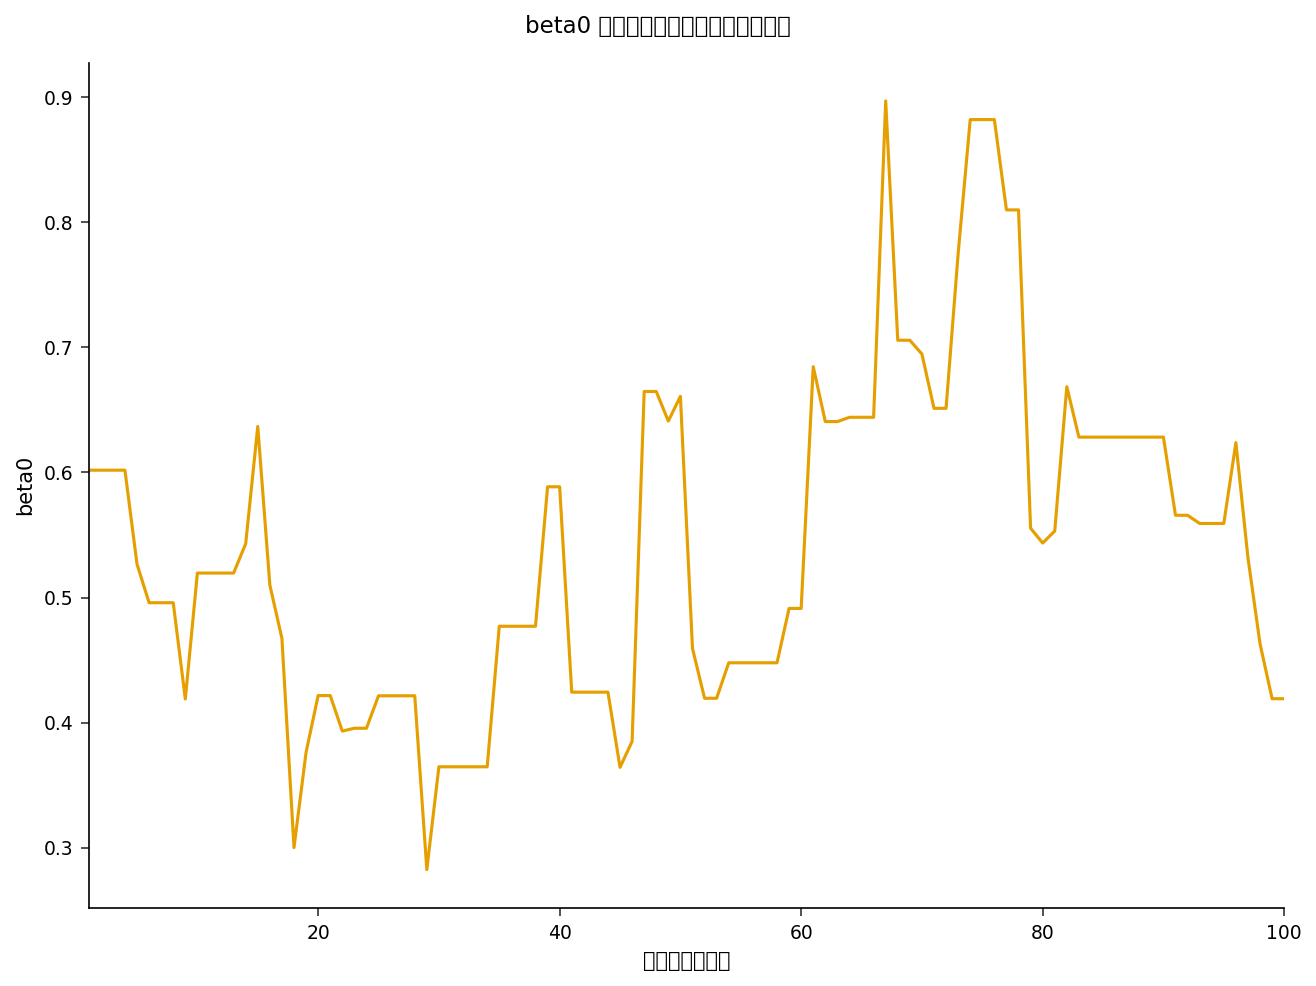

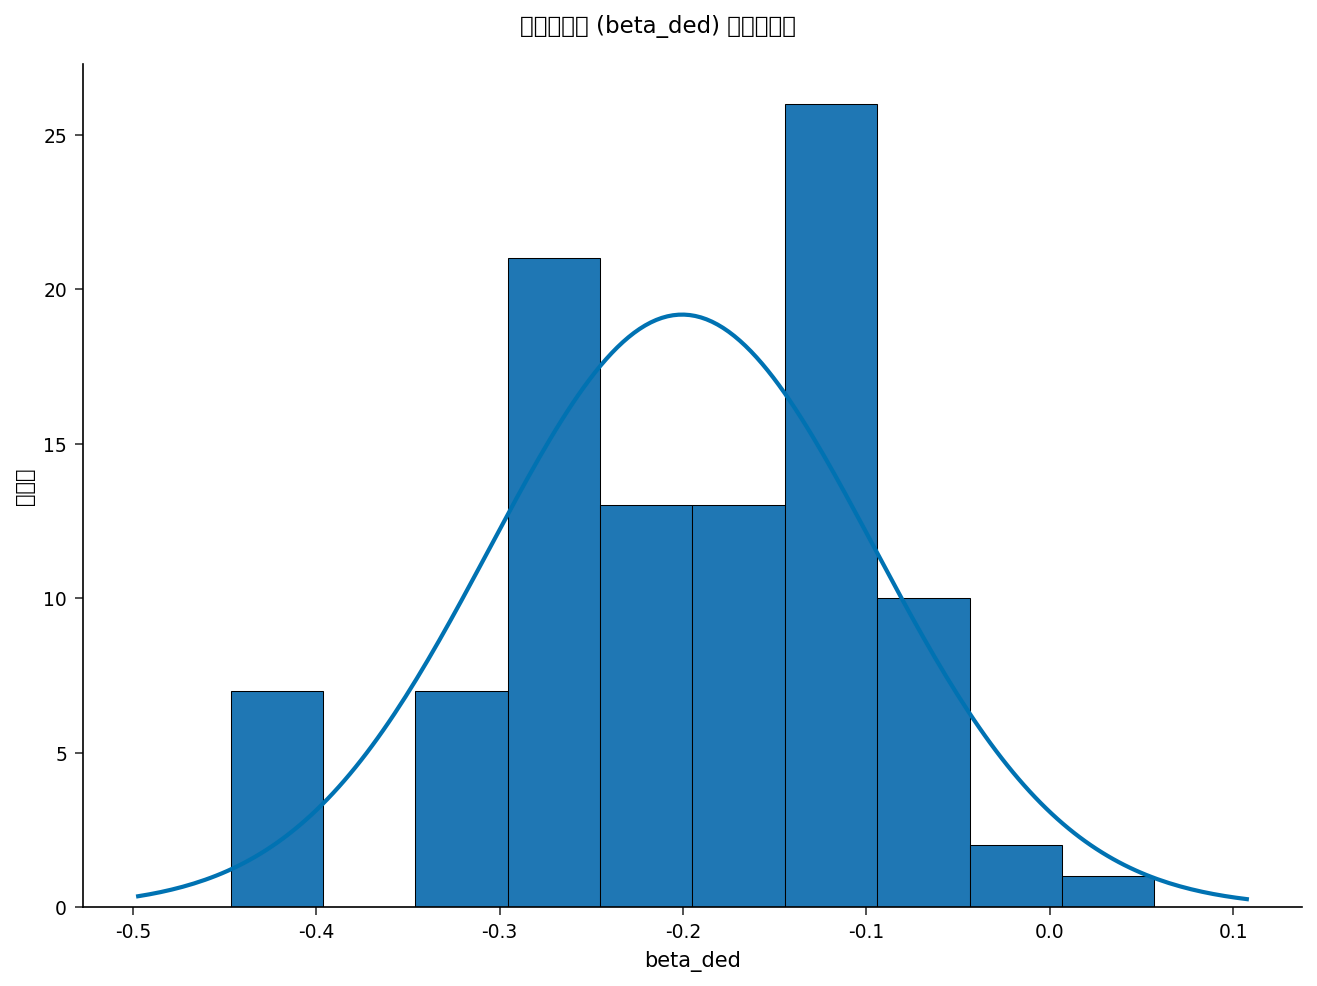

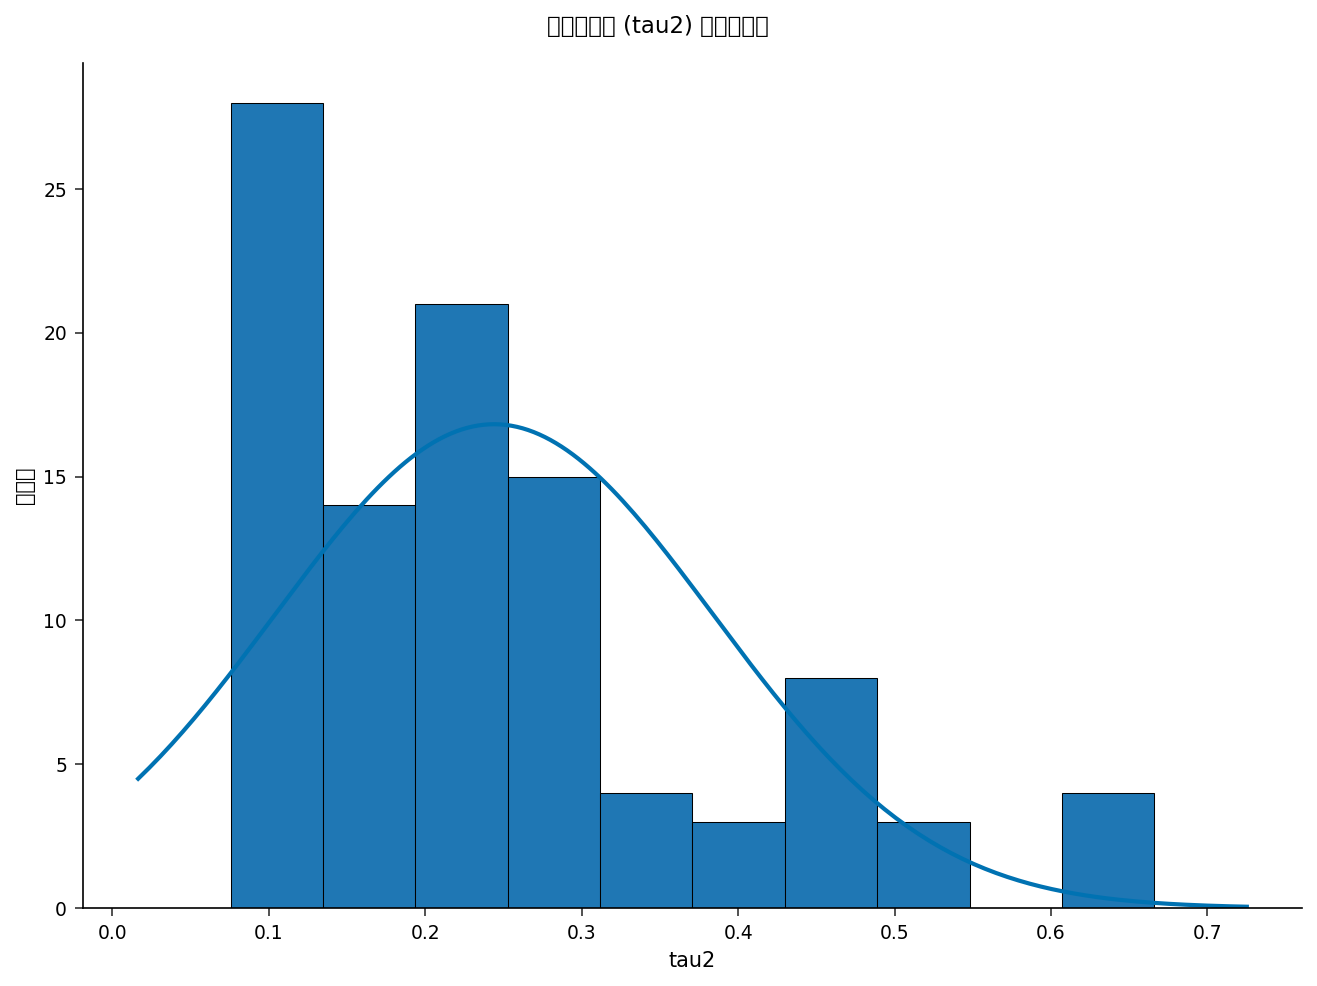

In [6]:
/* Step 5 数据视图中已将 region_sd 添加到 post 中 */
数据 post2;
    设置 post;
    region_sd = sqrt(tau2);
运行;

/* 基准对数频率的轨迹图 */
过程 SGPLOT 数据=post2;
    SERIES x=iter y=beta0;
    标题 'beta0 的轨迹图（已保存的后验抽样）';
    XAXIS 标签='已保存迭代次数';
    YAXIS 标签='beta0';
运行;

/* 免赔额斜率的后验密度 */
过程 SGPLOT 数据=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    标题 '免赔额斜率 (beta_ded) 的后验密度';
    XAXIS 标签='beta_ded';
    YAXIS 标签='百分比';
运行;

/* 区域间方差的后验密度 */
过程 SGPLOT 数据=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    标题 '区域间方差 (tau2) 的后验密度';
    XAXIS 标签='tau2';
    YAXIS 标签='百分比';
运行;

## 结果解读

**模型给出的结果：**

- **恢复的结构。** 后验区域效应（`post_mean_u`）在符号和排序上与预设真值（`true_eff`）一致：区域 5（真值 +0.40）最高，为 +0.36；区域 4（真值 -0.30）最低，为 -0.70；区域 1（真值 +0.05）接近中心，为 +0.20。免赔额斜率 `beta_ded` 落在 -0.13（为负，符合数据生成过程的设定，尽管由于 96 份保单的小样本而向零收缩），`beta0` 恢复出的基准对数频率为 0.43 —— 这证明层次化泊松似然和风险暴露偏移量的设定是正确的。
- **部分合并的实际效果。** 将步骤 4 收缩后的 `relativity` 与步骤 2 的原始频率进行比较。区域 5 的原始频率 3.41 被拉至相对值 1.43，区域 4 的原始值 0.45 被提升至相对值 0.49 —— 数据稀薄的区域被约束向整体组合中心靠拢，并带有**最宽的可信区间**，这正是精算师所期望的行为：不要因为少数几笔随机理赔而对某个区域收费过高或过低。
- **量化的不确定性。** `sqrt(tau2)` 的后验（均值约 0.48）衡量了在考虑免赔额结构和风险暴露之后仍然存在的真实区域间异质性程度 —— 这是费率区域相对值置信度以及资本/准备金不确定性分析的直接输入。
- **诊断与模型拟合。** 报告的 **DIC 为 246.7**，可作为将该层次化设定与更简单的合并或完全未合并方案进行比较的基准。有效样本量偏小（`beta_ded` 约为 525，随机效应与 `beta0` 为几十），且 **Geweke 诊断对全部三个被监控参数均发出警示** —— 轨迹图显示 `beta0` 在前 100 条已保存抽样中呈上升漂移趋势。在未授权模式下仅有 96 个保单年和较短的链条，这种未收敛现象是预期之中的；实际生产环境中的运行会延长预烧期和采样长度，并可能进行重新参数化，然后再依赖这些区间。

**为何在此使用贝叶斯方法：** 频率相对值直接用于定价，而监管机构越来越要求进行不确定性量化。PROC MCMC 为每个区域生成**完整的后验分布**，因此保险公司可以陈述，例如，"区域 4 的频率相对值在其后验均值 0.49 附近有一个 95% 可信区间" —— 这是经典点估计无法给出的陈述，而这恰恰对数据匮乏的小区域最有价值。